In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import casadi as ca
import itertools
%matplotlib widget

final vel: -8.046545176498537
height: 3.3000453250474955 m
final vel: -6.153749456856472
height: 1.9301035870418615 m
final vel: -5.227147166907239
height: 1.3926130226557782 m
final vel: -4.641165241964766
height: 1.0978804690734896 m
final vel: -4.2268338855048935
height: 0.9106077826530272 m
final vel: -3.908724961073558
height: 0.778701876723725 m


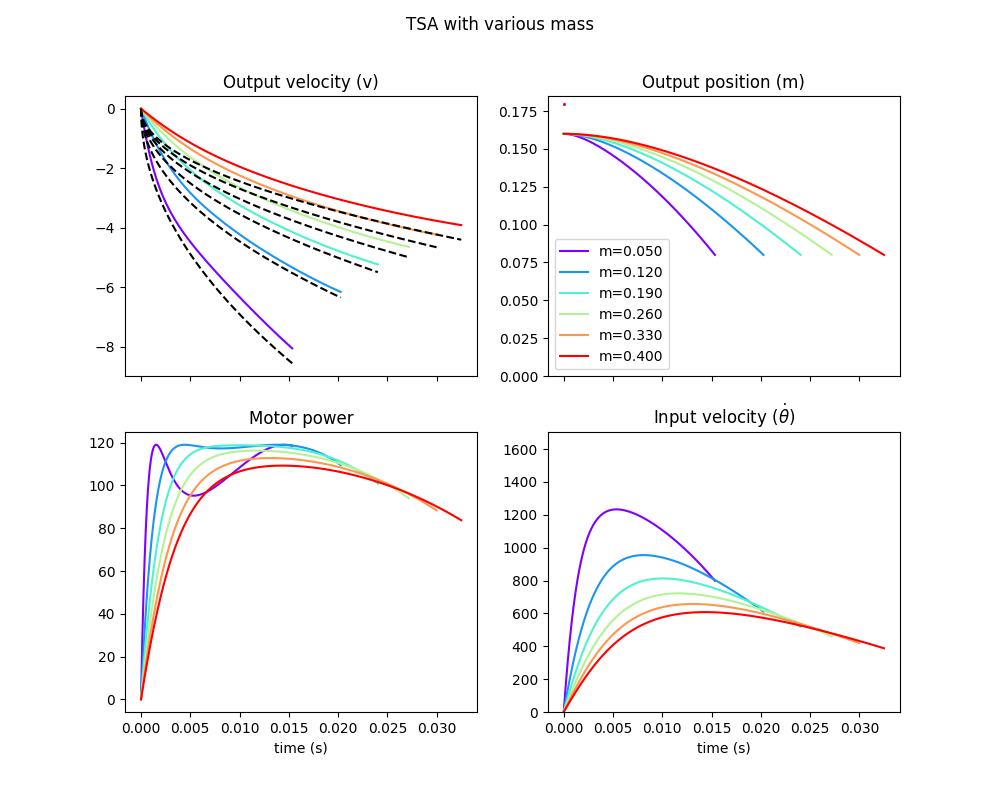

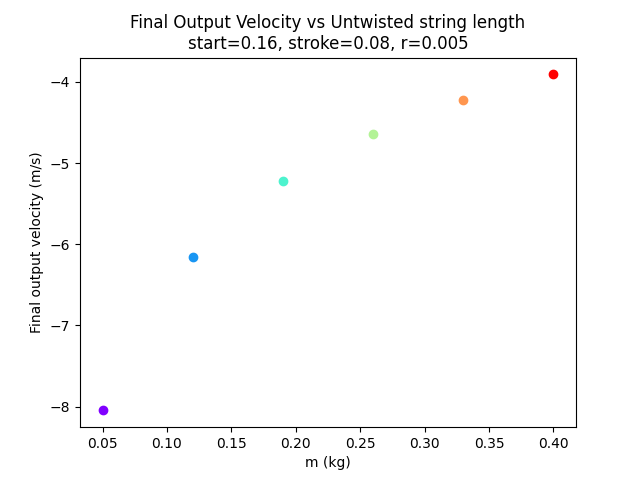

In [2]:
DT = 0.00001

def dynamics(t, states, variables, params):
    y = states[0] # output linear position (always positive, string base is 0)
    yd = states[1] # output linear velocity (negative)

    L = variables[0] # straightened twisted string length
    r = variables[1] # twisted string radius
    y0 = variables[2] # starting position (less than L to pretwist the string)

    stroke = params[0] # leg stroke length
    m = params[1] # load mass
    I = params[2] # rotor inertia
    tau_max = params[3] # motor stall torque
    w_max = params[4] # motor free speed
    g = params[5] # gravity

    # G = -y/(r*np.sqrt(L**2 - y**2))
    sqrt_term = np.sqrt(L**2 - y**2)
    G = -y / (r * sqrt_term)
    dG_dt = - (L**2) / (r * (sqrt_term**3)) * yd

    ydd = (G * tau_max*(1 - G*yd/w_max) + m*g - (I * G * dG_dt * yd)) / (m + I*G**2)

    return [yd, ydd]


def num_integration(variables, params):
    """
    Returns trajectory tuples: (thetas, theta_ds) using scipy.integrate.solve_ivp.
    The solution is sampled at N_points between t=0 and T_val.
    """
    y0 = variables[2] # starting position (less than L to pretwist the string)
    stroke = params[0] # leg stroke length

    def stroke_end_event(t, x):
        y, yd = x
        return y - (y0 - stroke)
    stroke_end_event.terminal = True
    stroke_end_event.direction = -1 #triggers if went from postive to negative
    
    initial_state = [y0, 0]
    end_time = 2
    t_eval = np.arange(0, end_time, DT)
    sol = solve_ivp(lambda t, states: dynamics(t, states, variables, params), [0, end_time], initial_state, events=stroke_end_event, t_eval=t_eval, method='RK45', vectorized=False)

    # sol.t may be shorter than t_eval if the event was triggered
    return sol.t, sol.y[0], sol.y[1]

def eval_and_plot(variables, params, axs=None, label=None, color=None):
    t_num, y_num, yd_num = num_integration(variables, params)
    print(f"final vel: {yd_num[-1]}")
    height = yd_num[-1]**2/(2*9.81)
    print(f"height: {height} m")

    L = variables[0]
    r = variables[1]
    y0 = variables[2]
    stroke = params[0]
    m = params[1]
    I = params[2]
    tau_max = params[3]
    w_max = params[4]
    g = params[5]


    theta0 = np.sqrt(L**2 - y0**2)/r
    theta_num = np.sqrt(L**2 - y_num**2)/r - theta0
    
    G = -y_num/(r*np.sqrt(L**2 - y_num**2))
    thetad_num = yd_num*G

    torque = tau_max*(1-thetad_num/w_max)
    power = torque*thetad_num

    # integrate power to get time series of energy with cumtrapz
    from scipy.integrate import cumulative_trapezoid
    energy_cum = cumulative_trapezoid(power, t_num, initial=0)

    # Calculate kinetic energy (should be equal to energy_cum):
    kinetic_energy = 0.5 * I * thetad_num**2 + 0.5 * m * yd_num**2

    if axs is None:
        fig, axs = plt.subplots(2, 2, sharex=True)

    if not hasattr(eval_and_plot, "color_cycle"):
        eval_and_plot.color_cycle = itertools.cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])
    if color is None:
        color = next(eval_and_plot.color_cycle)

    # axs[0,0].set_title('Motor position (θ)')
    # axs[0,0].plot(t_num, theta_num, color=color)
    axs[0,0].set_title('Output velocity (v)')
    axs[0,0].plot(t_num, yd_num, color=color)
    # axs[0,0].set_ylim(-8,0)
    # axs[0,0].set_xlim(0, 0.04)

    P_max = tau_max*w_max/4
    ideal_vels = -np.sqrt(2*P_max/m * t_num)
    axs[0,0].plot(t_num, ideal_vels, 'k--')
    # axs[0,0].set_ylim(0, None)

    axs[1,0].set_title('Motor power')
    # axs[1,0].plot(t_num, thetad_num, color=color)
    axs[1,0].plot(t_num, power, linestyle='-', color=color)
    # axs[1,0].set_title('Motor output energy (solid) and total KE (dashed)')
    # axs[1,0].plot(t_num, energy_cum, linestyle='-', color=color)
    # axs[1,0].plot(t_num, kinetic_energy, linestyle='--', color=color)
    
    axs[1,0].set_xlabel('time (s)')
    # axs[1,0].legend()


    axs[0,1].set_title('Output position (m)')
    axs[0,1].plot(t_num, y_num, label=label, color=color)
    axs[0,1].scatter(0, L, s=1, color=color)
    axs[0,1].set_ylim(0, max(L, axs[0,1].get_ylim()[1]))
    axs[0,1].legend()

    # axs[1,1].set_title('Output velocity (v)')
    # axs[1,1].plot(t_num, yd_num, color=color)
    axs[1,1].set_title('Input velocity ($\\dot{\\theta}$)')
    axs[1,1].plot(t_num, thetad_num, color=color)
    axs[1,1].set_xlabel('time (s)')
    axs[1,1].set_ylim(0, w_max)
    return yd_num[-1]  

variables = [
    0.180, # L
    0.005, # r
    0.160, # y0
]
params = [
    0.080, # stroke
    0.100,  # mass
    1e-6 * (37.4/1000/2) * (28.4/1000/2)**2, # I rotor inertia (cylinder approx. mass=half of 37.4g, diameter 28.4mm)
    # 0.5 * (37.4/1000/2) * (28.4/1000/2)**2, # I rotor inertia (cylinder approx. mass=half of 37.4g, diameter 28.4mm)
    0.2795,  # tau_max
    1704,  # w_max
    0 # g
]

fig, axs = plt.subplots(2, 2, sharex=True, figsize=(10,8))
# axs[1,0].axhline(0.2795*1704*0.25, color='k', linestyle=':')
fig.suptitle('TSA with various mass')


# L_values = np.arange(0.120, 0.200 + 0.0001, 0.008)
# colors = plt.cm.rainbow(np.linspace(0, 1, len(L_values)))

# fig, ax = plt.subplots(1, 1)
# ax.set_xlabel('L (m)')
# ax.set_ylabel('Final output velocity (m/s)')
# ax.set_title(f'Final Output Velocity vs Untwisted string length\nstart={variables[2]}, stroke={params[0]}, r={variables[1]}')
# for i,L in enumerate(L_values):
#     variables[0] = L
#     variables[2] = L-0.020
#     # params[0] = L*0.5
#     yd_final = eval_and_plot(variables, params, color=colors[i], axs=axs, label=f'L={L:.3f}')
#     ax.scatter(L, yd_final, color=colors[i], label=f'L={L:.3f}')

m_values = np.linspace(0.050, 0.400, 6)
colors = plt.cm.rainbow(np.linspace(0, 1, len(m_values)))

fig, ax = plt.subplots(1, 1)
ax.set_xlabel('m (kg)')
ax.set_ylabel('Final output velocity (m/s)')
ax.set_title(f'Final Output Velocity vs Untwisted string length\nstart={variables[2]}, stroke={params[0]}, r={variables[1]}')
for i,m in enumerate(m_values):
    params[1] = m
    # params[0] = L*0.5
    yd_final = eval_and_plot(variables, params, color=colors[i], axs=axs, label=f'm={m:.3f}')
    ax.scatter(m, yd_final, color=colors[i], label=f'm={m:.3f}')

final vel: -2.011763175506078
height: 0.2062788519022578 m


NameError: name 'L' is not defined

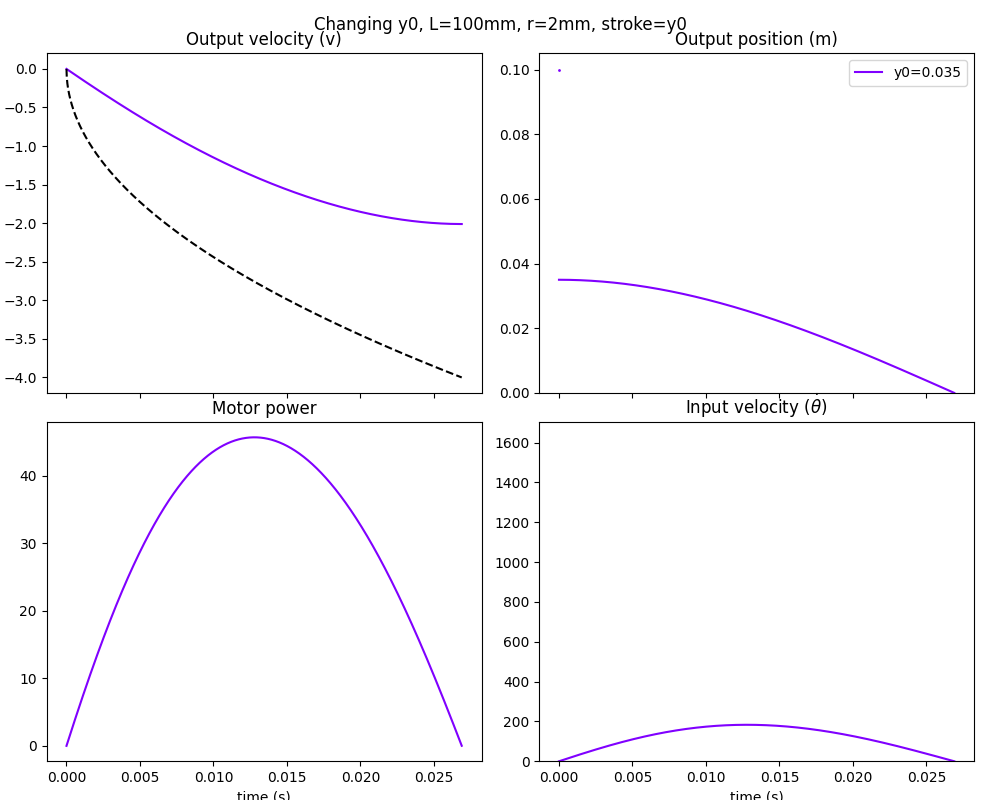

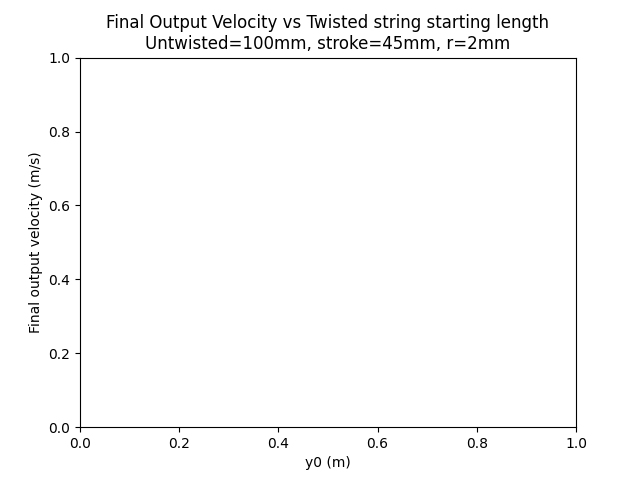

In [3]:
variables = [
    0.100, # L
    0.002, # r
    0.045, # y0
]
fig, axs = plt.subplots(2, 2, sharex=True, figsize=(10,8))
plt.suptitle("Changing y0, L=100mm, r=2mm, stroke=y0")
# axs[1,0].axhline(0.2795*1704*0.25, color='k', linestyle=':')

y0_values = np.arange(0.035, 0.095 + 0.0001, 0.005)
colors = plt.cm.rainbow(np.linspace(0, 1, len(y0_values)))
plt.tight_layout()
fig, ax = plt.subplots(1, 1)
ax.set_xlabel('y0 (m)')
ax.set_ylabel('Final output velocity (m/s)')
ax.set_title('Final Output Velocity vs Twisted string starting length\nUntwisted=100mm, stroke=45mm, r=2mm')
for i,y0 in enumerate(y0_values):
    variables[2] = y0
    params[0] = min(0.035, y0)
    # params[0] = y0
    yd_final = eval_and_plot(variables, params, color=colors[i], axs=axs, label=f'y0={y0:.3f}')
    ax.scatter(y0, yd_final, color=colors[i], label=f'L={L:.3f}')

/var/folders/fm/j5zsv9x1121cqbb30njg041r0000gn/T/ipykernel_6476/3834739900.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0,1].legend(title='L,r,y0')


L_var, r_var, y0_var, T_var, y_final, yd_final
[0.23692270940419288, 0.003440165310591859, 0.23592271436326628, 0.06097406619019525, 0.035922713475675334, -7.29978940688875]
final vel: -7.29344514334467
height: 2.711230482108968 m
[0.10513630250766162, 0.0015963987560404513, 0.10413630845509397, 0.05054071715106697, 0.00413630545690619, -6.238897737125835]
final vel: -6.235255050306734
height: 1.9815701091934574 m
[0.10994682813849554, 0.001630033202806773, 0.10894683551813479, 0.05464852179312847, 0.008946829294443214, -4.699088128844351]
final vel: -4.7044350618780255
height: 1.1280178007863049 m
[0.05167889161055724, 0.0006987326766173884, 0.05067890072615803, 0.04986579070069973, 0.000678891889492229, -4.1264404625804065]
final vel: -4.122288948157661
height: 0.8661195806372475 m


/var/folders/fm/j5zsv9x1121cqbb30njg041r0000gn/T/ipykernel_6476/929558679.py:19: RuntimeWarning: invalid value encountered in sqrt
  sqrt_term = np.sqrt(L**2 - y**2)


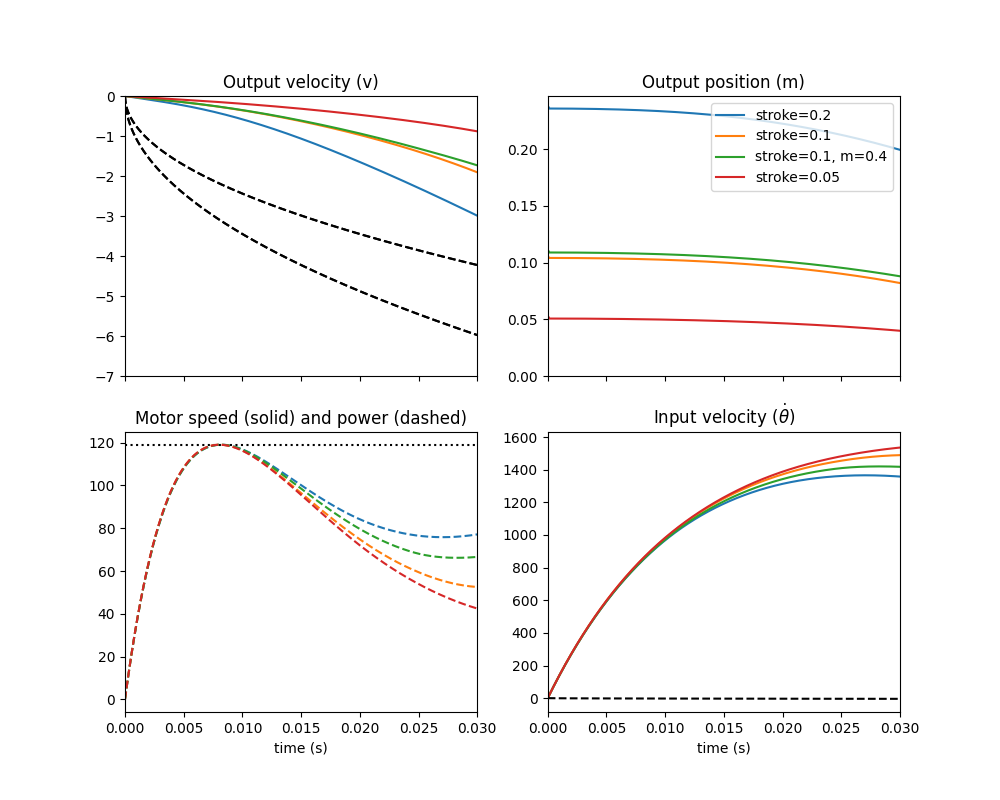

In [ ]:
def optimize(params, guess):
    stroke = params[0] # leg stroke length
    m = params[1] # load mass
    I = params[2] # rotor inertia
    tau_max = params[3] # motor stall torque
    w_max = params[4] # motor free speed
    g = params[5] # gravity

    state = ca.MX.sym('y', 2)
    L = ca.MX.sym('L')
    r = ca.MX.sym('r')
    y0 = ca.MX.sym('y0')
    T = ca.MX.sym('T')

    y = state[0]
    yd = state[1]

    discriminant = ca.fmax(L**2 - y**2, 1e-6) 
    sqrt_term = ca.sqrt(discriminant)
    G = -y / (r * sqrt_term)
    dG_dt = - (L**2) / (r * (sqrt_term**3)) * yd

    ydd = (G * tau_max*(1 - G*yd/w_max) + m*g - (I * G * dG_dt * yd)) / (m + I*G**2) #negative
    ode = ca.vertcat(
        T*yd,
        T*ydd
    )

    dae = {'x': state, 'p': ca.vertcat(L, r, y0, T), 'ode': ode}
    integrator = ca.integrator('F', 'rk', dae, {'tf': 1.0})

    opti = ca.Opti()
    L_var = opti.variable()
    r_var = opti.variable()
    y0_var = opti.variable()
    T_var = opti.variable()
    initial_state = ca.vertcat(y0_var, 0)
    res = integrator(x0=initial_state, p=ca.vertcat(L_var, r_var, y0_var, T_var))
    y_final = res['xf'][0]
    yd_final = res['xf'][1]

    opti.minimize(yd_final)

    opti.subject_to(L_var > stroke)
    opti.subject_to(L_var < 10)
    opti.subject_to(r_var > 0.0001)
    opti.subject_to(r_var < 0.100)
    opti.subject_to(y0_var > stroke)
    opti.subject_to(y0_var < L_var - 0.001)
    opti.subject_to(y0_var < 1.234)
    opti.subject_to(y_final > y0_var - stroke)
    opti.subject_to(y_final < y0_var)
    opti.subject_to(y_final > 0)

    opti.subject_to(T_var >= 0.001)
    opti.subject_to(T_var <= 2.0)

    # Set some initial guesses for the solver
    vars_list = [L_var, r_var, y0_var, T_var]
    for var, guess in zip(vars_list, guess):
        opti.set_initial(var, guess)

    # Solve
    opts = {'ipopt.print_level': 0, 'print_time': 0}
    opti.solver('ipopt', opts)
    sol = opti.solve()

    variables = []
    for i,varname in enumerate([L_var, r_var, y0_var, T_var, y_final, yd_final]):
        variables.append(sol.value(varname))

    return variables, sol, opti



fig, axs = plt.subplots(2, 2, sharex=True, figsize=(10,8))
eval_and_plot.color_cycle = itertools.cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])
guess = [0.100, 0.00165, 0.090, 0.03]
params = [
    0.200, # stroke
    0.2,  # m
    0.5 * (37.4/1000/2) * (28.4/1000/2)**2, # I rotor inertia (cylinder approx. mass=half of 37.4g, diameter 28.4mm)
    0.2795,  # tau_max
    1704,  # w_max
    9.81 # g
]
# axs[1,0].axhline(params[4]/2, color='k', linestyle=':')
P_max = params[3]*params[4]/4
axs[1,0].axhline(P_max, color='k', linestyle=':')
axs[0,1].legend(title='L,r,y0')
variables, sol, opti = optimize(params, guess)
print('L_var, r_var, y0_var, T_var, y_final, yd_final')
print(variables)
eval_and_plot(variables, params, axs, label=f'stroke={params[0]}')

# params[0] = 0.500
# variables, sol, opti = optimize(params, guess)
# print(variables)
# eval_and_plot(variables, params, axs, label=f'stroke={params[0]}')


params[0] = 0.100
variables, sol, opti = optimize(params, guess)
print(variables)
eval_and_plot(variables, params, axs, label=f'stroke={params[0]}')

params[0] = 0.100
params[1] = 0.4
variables, sol, opti = optimize(params, guess)
print(variables)
eval_and_plot(variables, params, axs, label=f'stroke={params[0]}, m={params[1]}')


params[0] = 0.050
variables, sol, opti = optimize(params, guess)
print(variables)
eval_and_plot(variables, params, axs, label=f'stroke={params[0]}')


times = np.linspace(0, 0.08, 100)
ideal_vels = -np.sqrt(2*P_max/params[1] * times)
axs[1,1].plot(times, ideal_vels, 'k--')


# params[0] = 0.200
# params[5] = 0.0 # no gravity
# variables, sol, opti = optimize(params, guess)
# print(variables)
# eval_and_plot(variables, params, axs, label=f'stroke={params[0]}, g={params[5]}')

solving stroke=0.05
solving stroke=0.052564102564102565
solving stroke=0.055128205128205134
solving stroke=0.057692307692307696
solving stroke=0.06025641025641026
solving stroke=0.06282051282051282
solving stroke=0.06538461538461539
solving stroke=0.06794871794871796
solving stroke=0.07051282051282051
solving stroke=0.07307692307692308


CasADi - 2025-12-25 22:10:01 WARNING("F:step failed: NaN detected for output xf, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:326]
CasADi - 2025-12-25 22:10:01 WARNING("F:step failed: NaN detected for output xf, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:326]
CasADi - 2025-12-25 22:10:01 WARNING("F:step failed: NaN detected for output xf, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:326]
CasADi - 2025-12-25 22:10:01 WARNING("F:step failed: NaN detected for output xf, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:326]
CasADi - 2025-12-25 22:10:01 WARNING("F:step failed: NaN detected for output xf, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:326]
CasADi - 2025-12-25 22:10:01 WARNING("F:step failed: NaN detected for output xf, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:326]
CasADi - 2025-12-25 22:10:01 WARNING("F:step failed: NaN detected for output xf, at (row 0, col 0).") [.../casadi/core/oracle_function.c

solving stroke=0.07564102564102565
solving stroke=0.0782051282051282
solving stroke=0.08076923076923077
solving stroke=0.08333333333333334
solving stroke=0.0858974358974359
solving stroke=0.08846153846153847
solving stroke=0.09102564102564104
solving stroke=0.09358974358974359
solving stroke=0.09615384615384616
solving stroke=0.09871794871794873
solving stroke=0.10128205128205128
solving stroke=0.10384615384615385
solving stroke=0.10641025641025642
solving stroke=0.10897435897435898
solving stroke=0.11153846153846154
solving stroke=0.1141025641025641
solving stroke=0.11666666666666667
solving stroke=0.11923076923076924
solving stroke=0.12179487179487179
solving stroke=0.12435897435897436
solving stroke=0.12692307692307692
solving stroke=0.12948717948717947
solving stroke=0.13205128205128205
solving stroke=0.13461538461538464
solving stroke=0.1371794871794872
solving stroke=0.13974358974358975
solving stroke=0.1423076923076923
solving stroke=0.14487179487179486
solving stroke=0.14743589

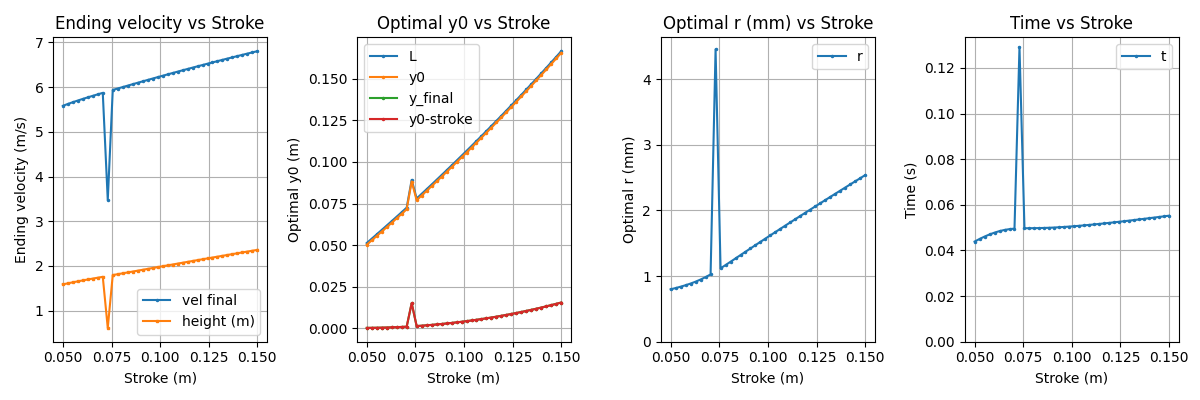

In [ ]:
import numpy as np

stroke_vals = np.linspace(0.05, 0.15, 40)

results_arr = np.zeros((len(stroke_vals), 6))  # variables = [L, r, y0, T, y_final, yd_final]
guess = [2.1, 0.00165, 2, 0.05]  # Initial guess for the first run
for i, stroke in enumerate(stroke_vals):
    print(f"solving stroke={stroke}")
    params = [
        stroke, # stroke
        0.2,  # m
        0.5 * (37.4/1000/2) * (28.4/1000/2)**2, # I (rotor inertia, same as before)
        0.2795,  # tau_max
        1704,  # w_max
        9.81 # g
    ]

    guess[0] = stroke+0.5
    guess[2] = stroke+0.3


    try:
        variables, sol, opti = optimize(params, guess)
    except Exception as e:
        print(f"Optimization failed at stroke={stroke} with exception: {e}")
        variables = [np.nan]*6
        sol = None
        opti = None
    # variables should be [L, r, y0, T, y_final, yd_final]
    results_arr[i, :] = variables
    # Use current solution as guess for the next run (except for y_final and yd_final)

    
    guess = variables[:4]
    

fig2, ax2 = plt.subplots(1, 4, figsize=(12,4))
L_opt = results_arr[:,0]
r_opt = results_arr[:,1]
y0_opt = results_arr[:,2]
T_opt = results_arr[:,3]
y_final = results_arr[:,4]
yd_final = results_arr[:,5]

ax2[0].plot(stroke_vals, np.abs(yd_final), marker='o', markersize=1.5, label='vel final')
height = yd_final**2 / (2 * 9.81)
ax2[0].plot(stroke_vals, height, marker='s', markersize=1.5, label='height (m)')
ax2[0].set_xlabel("Stroke (m)")
ax2[0].set_ylabel("Ending velocity (m/s)")
ax2[0].set_title("Ending velocity vs Stroke")

ax2[1].plot(stroke_vals, L_opt, marker='o', markersize=1.5, label='L')
ax2[1].plot(stroke_vals, y0_opt, marker='o', markersize=1.5, label='y0')
ax2[1].plot(stroke_vals, y_final, marker='o', markersize=1.5, label='y_final')
ax2[1].plot(stroke_vals, y0_opt-stroke_vals, marker='o', markersize=1.5, label='y0-stroke')
ax2[1].set_xlabel("Stroke (m)")
ax2[1].set_ylabel("Optimal y0 (m)")
ax2[1].set_title("Optimal y0 vs Stroke")

ax2[2].plot(stroke_vals, r_opt*1000, marker='o', markersize=1.5, label='r')
ax2[2].set_xlabel("Stroke (m)")
ax2[2].set_ylabel("Optimal r (mm)")
ax2[2].set_title("Optimal r (mm) vs Stroke")
ax2[2].set_ylim(0, None)

ax2[3].plot(stroke_vals, T_opt, marker='o', markersize=1.5, label='t')
ax2[3].set_xlabel("Stroke (m)")
ax2[3].set_ylabel("Time (s)")
ax2[3].set_title("Time vs Stroke")
ax2[3].set_ylim(0, None)

for ax in ax2:
    ax.grid()
    ax.legend()

plt.tight_layout()
plt.show()

solving mass=0.01
solving mass=0.02
solving mass=0.03
solving mass=0.04
solving mass=0.05
solving mass=0.060000000000000005
solving mass=0.06999999999999999
solving mass=0.08
solving mass=0.09
solving mass=0.09999999999999999
solving mass=0.11
solving mass=0.12
solving mass=0.13
solving mass=0.14
solving mass=0.15000000000000002
solving mass=0.16
solving mass=0.17
solving mass=0.18000000000000002
solving mass=0.19
solving mass=0.2
solving mass=0.21000000000000002
solving mass=0.22
solving mass=0.23
solving mass=0.24000000000000002
solving mass=0.25


CasADi - 2025-12-25 22:10:52 WARNING("F:step failed: NaN detected for output xf, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:326]
CasADi - 2025-12-25 22:10:52 WARNING("F:step failed: NaN detected for output xf, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:326]
CasADi - 2025-12-25 22:10:52 WARNING("F:step failed: NaN detected for output xf, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:326]
CasADi - 2025-12-25 22:10:52 WARNING("F:step failed: NaN detected for output xf, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:326]
CasADi - 2025-12-25 22:10:52 WARNING("F:step failed: NaN detected for output xf, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:326]
CasADi - 2025-12-25 22:10:52 WARNING("F:step failed: NaN detected for output xf, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:326]
CasADi - 2025-12-25 22:10:52 WARNING("F:step failed: NaN detected for output xf, at (row 0, col 0).") [.../casadi/core/oracle_function.c

solving mass=0.26
solving mass=0.27
solving mass=0.28
solving mass=0.29000000000000004
solving mass=0.3
solving mass=0.31
solving mass=0.32


CasADi - 2025-12-25 22:10:59 WARNING("F:step failed: Inf detected for output xf, at (row 1, col 0).") [.../casadi/core/oracle_function.cpp:326]
CasADi - 2025-12-25 22:10:59 WARNING("F:step failed: NaN detected for output xf, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:326]
CasADi - 2025-12-25 22:10:59 WARNING("F:step failed: NaN detected for output xf, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:326]
CasADi - 2025-12-25 22:10:59 WARNING("F:step failed: NaN detected for output xf, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:326]
CasADi - 2025-12-25 22:10:59 WARNING("F:step failed: NaN detected for output xf, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:326]
CasADi - 2025-12-25 22:10:59 WARNING("F:step failed: NaN detected for output xf, at (row 0, col 0).") [.../casadi/core/oracle_function.cpp:326]
CasADi - 2025-12-25 22:10:59 WARNING("F:step failed: NaN detected for output xf, at (row 0, col 0).") [.../casadi/core/oracle_function.c

solving mass=0.33
solving mass=0.34
solving mass=0.35000000000000003
solving mass=0.36000000000000004
solving mass=0.37
solving mass=0.38
solving mass=0.39
solving mass=0.4
solving mass=0.41000000000000003
solving mass=0.42000000000000004
solving mass=0.43
solving mass=0.44
solving mass=0.45
solving mass=0.46
solving mass=0.47000000000000003
solving mass=0.48000000000000004
solving mass=0.49
solving mass=0.5


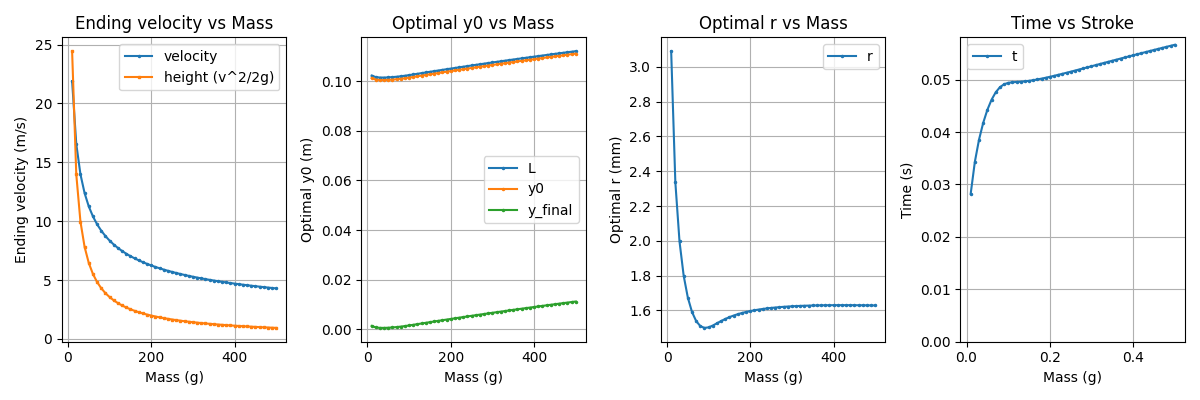

In [ ]:
import numpy as np

# Range of mass values from 10g to 2kg (inclusive), e.g., 20 points
mass_vals = np.linspace(0.01, 0.50, 50)  # Mass in kg

results_arr = np.zeros((len(mass_vals), 6))  # variables = [L, r, y0, T, y_final, yd_final]
guess = [0.150, 0.00165, 0.12, 0.01]  # Initial guess for the first run

for i, mass in enumerate(mass_vals):
    print(f"solving mass={mass}")
    params = [
        0.1, # stroke (fixed for this analysis)
        mass,  # m (variable)
        0.5 * (37.4/1000/2) * (28.4/1000/2)**2, # I (rotor inertia, same as before)
        0.2795,  # tau_max
        1704,  # w_max
        9.81 # g
    ]
    guess[0] = stroke+0.7
    guess[2] = stroke+0.5
    variables, sol, opti = optimize(params, guess)
    # variables should be [L, r, y0, T, y_final, yd_final]
    results_arr[i, :] = variables
    # Use current solution as guess for the next run (except for y_final and yd_final)
    guess = variables[:4]

fig2, ax2 = plt.subplots(1, 4, figsize=(12,4))
L_opt = results_arr[:,0]
r_opt = results_arr[:,1]
y0_opt = results_arr[:,2]
T_opt = results_arr[:,3]
y_final = results_arr[:,4]
yd_final = results_arr[:,5]

ax2[0].plot(mass_vals*1000, np.abs(yd_final), marker='o', markersize=1.5, label='velocity')
height = yd_final**2 / (2 * 9.81)
ax2[0].plot(mass_vals*1000, height, marker='s', markersize=1.5, label='height (v^2/2g)')
ax2[0].set_xlabel("Mass (g)")
ax2[0].set_ylabel("Ending velocity (m/s)")
ax2[0].set_title("Ending velocity vs Mass")

ax2[1].plot(mass_vals*1000, L_opt, marker='o', markersize=1.5, label='L')
ax2[1].plot(mass_vals*1000, y0_opt, marker='o', markersize=1.5, label='y0')
ax2[1].plot(mass_vals*1000, y_final, marker='o', markersize=1.5, label='y_final')
ax2[1].set_xlabel("Mass (g)")
ax2[1].set_ylabel("Optimal y0 (m)")
ax2[1].set_title("Optimal y0 vs Mass")

ax2[2].plot(mass_vals*1000, r_opt*1000, marker='o', markersize=1.5, label='r')
ax2[2].set_xlabel("Mass (g)")
ax2[2].set_ylabel("Optimal r (mm)")
ax2[2].set_title("Optimal r vs Mass")

ax2[3].plot(mass_vals, T_opt, marker='o', markersize=1.5, label='t')
ax2[3].set_xlabel("Mass (g)")
ax2[3].set_ylabel("Time (s)")
ax2[3].set_title("Time vs Stroke")
ax2[3].set_ylim(0, None)

for ax in ax2:
    ax.grid()
    ax.legend()

plt.tight_layout()
plt.show()

final vel: -4.448584293629306
height: 1.008659644114442 m
final vel: -4.879373726167195
height: 1.2134703343328612 m
final vel: -5.162263001268588
height: 1.3582548060278579 m
final vel: -5.333386063301025
height: 1.449796478094475 m
final vel: -5.431122527101863
height: 1.503419566992524 m
final vel: -5.480805930036878
height: 1.5310516637475742 m
final vel: -5.4969125005625665
height: 1.5400635595739556 m
final vel: -5.499889291035459
height: 1.5417320190441655 m
final vel: -5.477913697428503
height: 1.5294362118488694 m
final vel: -5.440260557710474
height: 1.5084829223129599 m


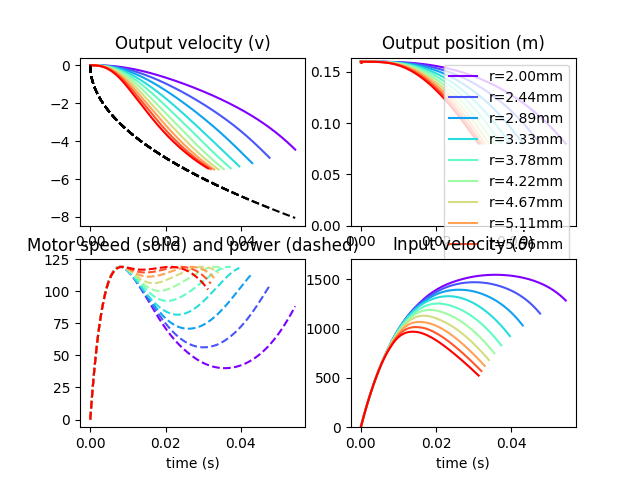

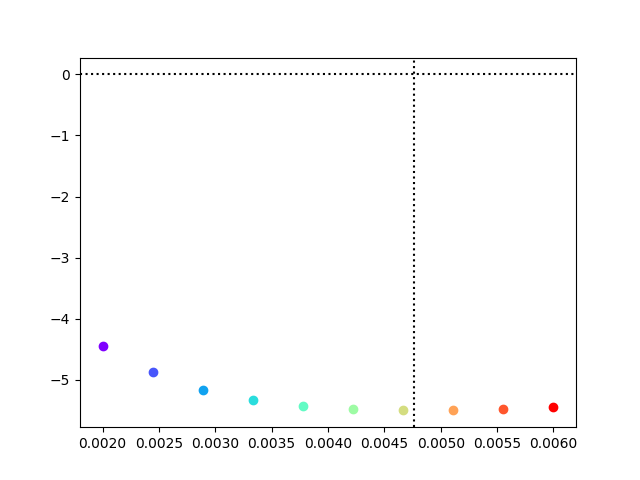

In [ ]:
r_values = np.linspace(0.002, 0.006, 10)  # Choose several r values (in meters) to test
L_fixed = 0.160001
y0_fixed = 0.160
colors_r = plt.cm.rainbow(np.linspace(0, 1, len(r_values)))

fig, axs = plt.subplots(2, 2)
fig, ax = plt.subplots(1, 1)

for j, r in enumerate(r_values):
    variables = [
        L_fixed,  # L
        r,        # r (varied)
        y0_fixed, # y0
    ]
    params = [
        0.080, # stroke
        0.2,  # m
        0.5 * (37.4/1000/2) * (28.4/1000/2)**2, # I rotor inertia
        0.2795,  # tau_max
        1704,  # w_max
        9.81 # g
    ]
    yd_final = eval_and_plot(variables, params, color=colors_r[j], axs=axs, label=f"r={r*1000:.2f}mm")
    ax.scatter(r, yd_final, color=colors_r[j], label=f'r={r:.3f}')
ax.axhline(0, color='k', linestyle=':')
ax.axvline(0.004765, color='k', linestyle=':')

final vel: -5.874949231527728
height: 1.7591757631512863 m
final vel: -6.138501305082191
height: 1.92055037066747 m
final vel: -6.3511733234040175
height: 2.0559328534107455 m
final vel: -6.496486059851144
height: 2.1510872133455776 m
final vel: -6.600779691253944
height: 2.2207080801463053 m
final vel: -6.625208831029147
height: 2.2371759457057383 m
final vel: -6.6303700527552305
height: 2.240662947832487 m
final vel: -6.618229258267494
height: 2.2324647561155913 m
final vel: -6.594942264215922
height: 2.2167820320255567 m
final vel: -6.558699740706163
height: 2.192484316449495 m
final vel: -6.518970489361065
height: 2.166002866521939 m
final vel: -6.457975787442672
height: 2.1256601055655353 m
final vel: -6.401102284976658
height: 2.088384835001702 m
final vel: -6.346703593716397
height: 2.0530400869771976 m
final vel: -6.289654335591333
height: 2.016297230439493 m
final vel: -6.233526818385424
height: 1.9804717938598522 m
final vel: -6.177449612544975
height: 1.9449991700067306 m
fi

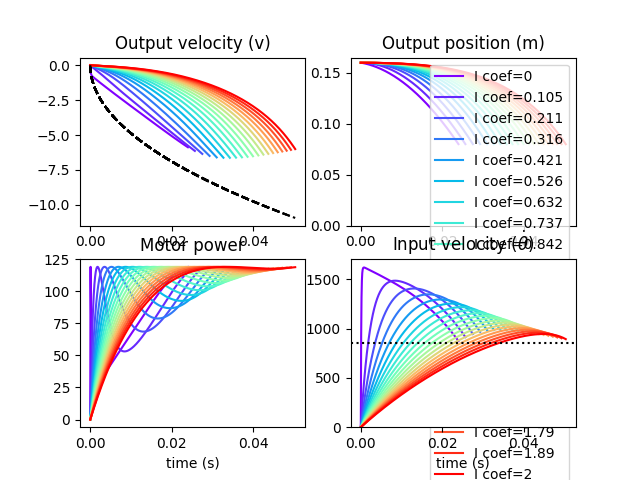

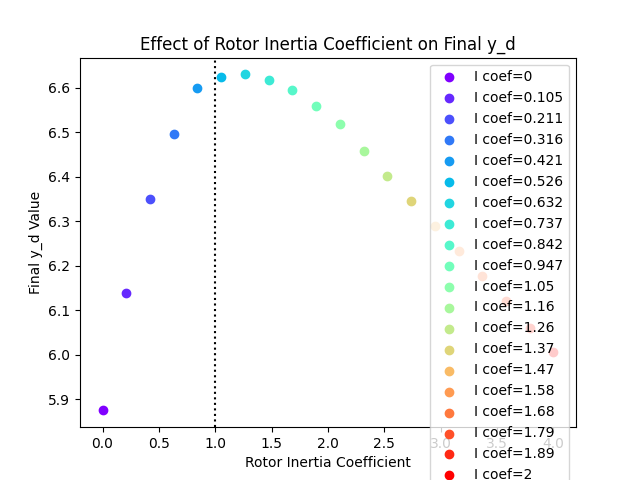

In [8]:
# Vary rotor inertia coefficient (from 1e-3 to 1), keep L fixed.
inertia_coeffs = np.linspace(0.00, 2, 20)  # From 1e-3 to 1, 20 points
L_fixed = 0.161
r_fixed = 0.00385
y0_fixed = 0.160
colors_I = plt.cm.rainbow(np.linspace(0, 1, len(inertia_coeffs)))

fig, axs = plt.subplots(2, 2)
fig, ax = plt.subplots(1, 1)

for j, coeff in enumerate(inertia_coeffs):
    I_rotor = coeff * (37.4/1000/2) * (28.4/1000/2)**2
    variables = [
        L_fixed,    # L (fixed)
        r_fixed,    # r (fixed)
        y0_fixed,   # y0 (fixed)
    ]
    params = [
        0.080,     # stroke
        0.1,       # m
        I_rotor,   # I rotor inertia (varied)
        0.2795,    # tau_max
        1704,      # w_max
        9.81       # g
    ]
    label_str = f"I coef={coeff:.3g}"
    yd_final = eval_and_plot(variables, params, color=colors_I[j], axs=axs, label=label_str)
    ax.scatter(coeff*2, abs(yd_final), color=colors_I[j], label=label_str)

axs[1,1].axhline(params[4]/2, color='k', linestyle=':')

# ax.axhline(0, color='k', linestyle=':')
ax.set_xlabel("Rotor Inertia Coefficient")
ax.set_ylabel("Final y_d Value")
ax.set_title("Effect of Rotor Inertia Coefficient on Final y_d")
ax.axvline(1, color='k', linestyle=':', label='1x (original)')
ax.legend()

final vel: -7.1464722057593155
height: 2.603061416294109 m


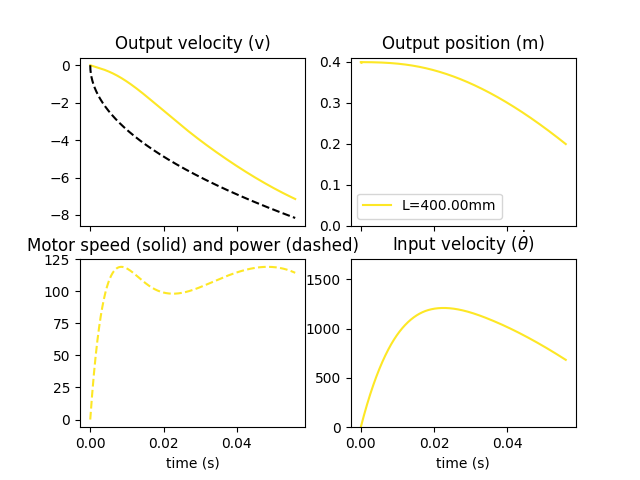

In [ ]:
variables = [
    0.4,         # L (varied)
    0.006,   # r
    0.4-0.001,  # y0
]
params = [
    0.200, # stroke
    0.2,  # m
    0.5 * (37.4/1000/2) * (28.4/1000/2)**2, # I rotor inertia
    0.2795,  # tau_max
    1704,  # w_max
    9.81 # g
]
yd_final = eval_and_plot(variables, params, color=colors_L[j], label=f"L={variables[0]*1000:.2f}mm")

final vel: -7.108312761397172
height: 2.5753369171173235 m
final vel: -7.260770019899471
height: 2.6869919103909767 m
final vel: -7.290155768144942
height: 2.7087854803168687 m
final vel: -7.232200175936466
height: 2.665887838165925 m
final vel: -7.12901268073896
height: 2.59035789001717 m
final vel: -7.000302281660161
height: 2.4976672800518074 m
final vel: -6.857675578042522
height: 2.3969273360693593 m
final vel: -6.708934991188333
height: 2.294077916207503 m
final vel: -6.560116892115833
height: 2.193431887778975 m
final vel: -6.41164984069758
height: 2.09527286848712 m
final vel: -7.1464722057593155
height: 2.603061416294109 m


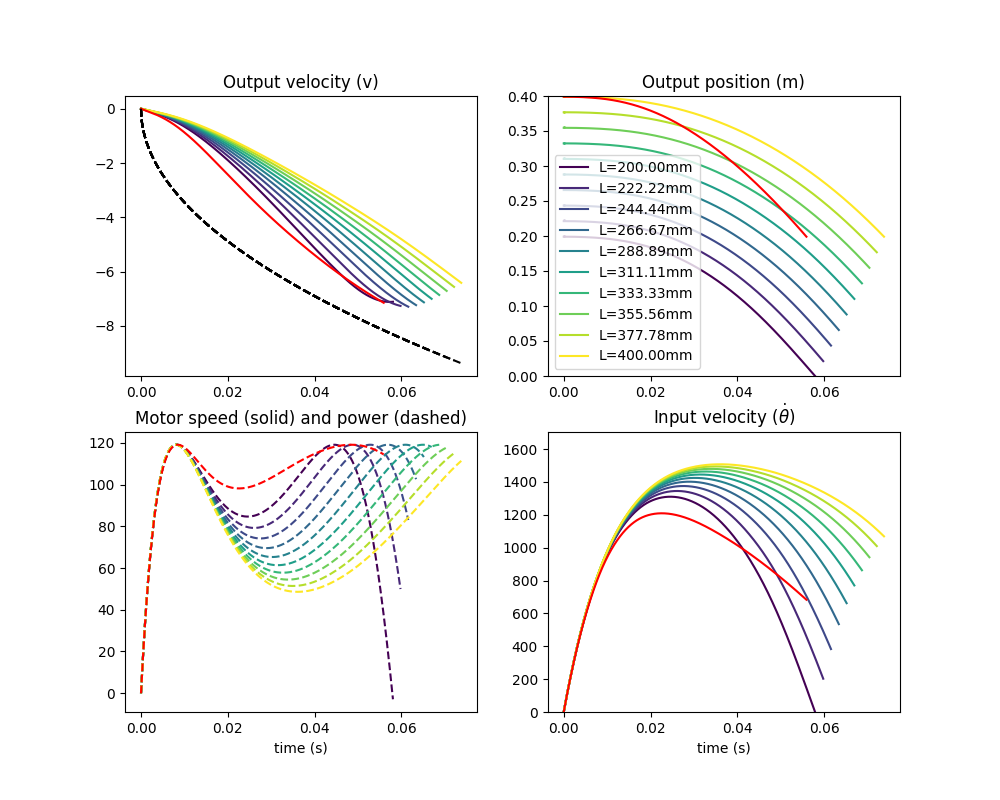

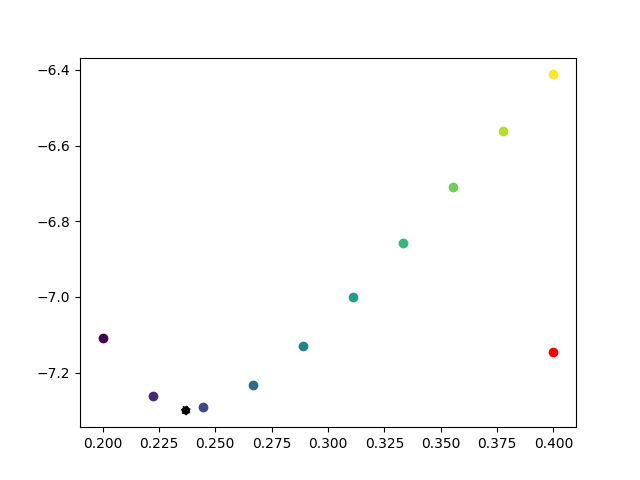

In [ ]:
L_values = np.linspace(0.200, 0.4, 10)  # Choose several L values (in meters) to test
r_fixed = 0.00344
y0_fixed = L_values-0.001
colors_L = plt.cm.viridis(np.linspace(0, 1, len(L_values)))

fig, axs = plt.subplots(2, 2, figsize=(10,8))
fig, ax = plt.subplots(1, 1)

for j, L in enumerate(L_values):
    variables = [
        L,         # L (varied)
        r_fixed,   # r
        L-0.001,  # y0
    ]
    params = [
        0.200, # stroke
        0.2,  # m
        0.5 * (37.4/1000/2) * (28.4/1000/2)**2, # I rotor inertia
        0.2795,  # tau_max
        1704,  # w_max
        9.81 # g
    ]
    yd_final = eval_and_plot(variables, params, color=colors_L[j], axs=axs, label=f"L={L*1000:.2f}mm")
    ax.scatter(L, yd_final, color=colors_L[j], label=f'L={L:.3f}')
ax.scatter(0.236923, -7.3, color='k', linestyle=':')


variables = [
    0.4,         # L (varied)
    0.006,   # r
    0.4-0.001,  # y0
]
params = [
    0.200, # stroke
    0.2,  # m
    0.5 * (37.4/1000/2) * (28.4/1000/2)**2, # I rotor inertia
    0.2795,  # tau_max
    1704,  # w_max
    9.81 # g
]
yd_final = eval_and_plot(variables, params, color='red', axs=axs)
ax.scatter(L, yd_final, color='red', label=f'{variables}')